# div26 — Single-Condition Regulatory Dynamics View

Simplified analysis that fixes a single angle condition and shows how each
regulatory dynamic affects the five metrics.  Below the charts, example
lineages are drawn from the **low (10th pctile)**, **mid (50th pctile)**,
and **high (90th pctile)** of each metric distribution per regulatory regime.

All data are from `data/sim/processed_sweep/`.  Run
`make preprocess-data` before executing this notebook.

---
## Section 0 — Setup

In [47]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_raw, load_raw_snapshot_full, load_sim_npz

PROC_DIR    = REPO_ROOT / 'data/sim/processed_sweep'
FIGURES_DIR = PROC_DIR / 'figures/analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim     = pd.read_csv(PROC_DIR / 'sim_metrics_last.csv')
run_idx = pd.read_csv(PROC_DIR / 'sim_run_index.csv', dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)
exp     = pd.read_csv(REPO_ROOT / 'data/exp/processed/exp_summary.csv')

print('sim rows:    ', len(sim))
print('run_idx rows:', len(run_idx))
print('exp genotypes:', list(exp['genotype']))
print('run_idx cols: ', list(run_idx.columns))

sim rows:     15500
run_idx rows: 15500
exp genotypes: ['mudmut', 'nanobody', 'wt']
run_idx cols:  ['condition', 'npz_path', 'npz_row', 'sim_id', 'run_id', 'time_id', 'n_nb', 'n_progeny', 'cells_path', 'locs_path']


In [48]:
METRICS = ['lin_area_vox', 'n_pros', 'n_dpn', 'dpn_area_vox', 'avg_dpn_area_vox']
METRIC_LABELS = {
    'lin_area_vox':     'Lineage area (vox)',
    'n_pros':           'Pros count',
    'n_dpn':            'NB count',
    'dpn_area_vox':     'Total NB area (vox)',
    'avg_dpn_area_vox': 'Avg NB area (vox/cell)',
}
TOP3 = ['lin_area_vox', 'n_pros', 'n_dpn']

# exp_summary.csv: wide format — columns are {metric}_mean / {metric}_std
wt_row = exp[exp['genotype'] == 'wt'].iloc[0]
mm_row = exp[exp['genotype'] == 'mudmut'].iloc[0]

wt_ref = {m: (float(wt_row[f'{m}_mean']), float(wt_row[f'{m}_std'])) for m in METRICS}
mm_ref = {m: (float(mm_row[f'{m}_mean']), float(mm_row[f'{m}_std'])) for m in METRICS}

print(f'  {"Metric":<20} {"WT mean":>10} {"WT std":>10} {"MM mean":>10} {"MM std":>10}')
print('  ' + '-' * 65)
for m in METRICS:
    print(f'  {m:<20} {wt_ref[m][0]:>10.1f} {wt_ref[m][1]:>10.1f} '
          f'{mm_ref[m][0]:>10.1f} {mm_ref[m][1]:>10.1f}')

  Metric                  WT mean     WT std    MM mean     MM std
  -----------------------------------------------------------------
  lin_area_vox             5568.4     1397.9     4074.9     1102.4
  n_pros                     44.9       21.7       36.9       20.5
  n_dpn                       1.0        0.0        1.8        0.9
  dpn_area_vox              577.0      473.8      320.1      257.5
  avg_dpn_area_vox          577.0      473.8      217.9      217.3


In [49]:
# ── Single angle condition for this notebook ──────────────────────────────────
# div N(0,26) · rot N(0,30) · both means = 0
# (div26 sweep uses σ=26 for all conditions; the rot σ=30 adds apical-axis spread)
SIMPLE_TAG  = 'D0S26_R0S30'
SIMPLE_COND = 'mudmut_divMean0Stdev26_rotMean0Stdev30'

# WT reference condition (divMean0Stdev26, no rotation perturbation)
WT_COND = 'wt_divMean0Stdev26'
WT_TAG  = 'D0S26'

# Sim-series IDs
MM_VCV1_IDS = ['sim41', 'sim42', 'sim43', 'sim44', 'sim45']
MM_VCV0_IDS = ['sim51', 'sim52', 'sim53', 'sim54', 'sim55']

sim_mm = sim[
    (sim['genotype'] == 'mudmut') &
    (sim['condition'] == SIMPLE_COND)
].copy()

sim_wt = sim[
    (sim['genotype'] == 'wt') &
    (sim['condition'] == WT_COND)
].copy()

present = set(sim['condition'].unique())
for cond, label in [(SIMPLE_COND, 'mudmut'), (WT_COND, 'WT ref')]:
    flag = '✓' if cond in present else '✗ MISSING'
    df = sim_mm if label == 'mudmut' else sim_wt
    print(f'{flag}  {cond}  [{label}]')
    print(f'  {len(df)} rows  ·  VCV modes: {sorted(df["critical_volume_mode"].unique())}')

✓  mudmut_divMean0Stdev26_rotMean0Stdev30  [mudmut]
  500 rows  ·  VCV modes: [np.int64(0), np.int64(1)]
✓  wt_divMean0Stdev26  [WT ref]
  500 rows  ·  VCV modes: [np.int64(0), np.int64(1)]


In [45]:
import npa.sim_viz as _sim_viz_mod

# Override colours in the already-imported module so render_raw picks them up
# even if the kernel imported sim_viz before the constants were updated on disk.
_sim_viz_mod.POP2_COLOR = '#4a96b7'   # GMC
_sim_viz_mod.POP3_COLOR = '#00a6a4'   # Neuron

NB_COLOR   = _sim_viz_mod.NB_COLOR
POP2_COLOR = _sim_viz_mod.POP2_COLOR
POP3_COLOR = _sim_viz_mod.POP3_COLOR

REG_DYN_ORDER  = ['NONE', 'NB-ABM', 'VOL-ABM', 'NB-PDE', 'VOL-PDE']
REG_DYN_COLORS = {
    'NONE':    '#888888',
    'NB-ABM':  '#4e9ed4',
    'VOL-ABM': '#5ab454',
    'NB-PDE':  '#e87b39',
    'VOL-PDE': '#d84444',
}


def fold_change_log(values, ref_mean):
    return np.log10(np.asarray(values, dtype=float) / ref_mean)


def draw_example_lineage(condition, sim_id, run_id=None, title='', ax=None):
    """
    Load the raw CELLS/LOCATIONS JSON and render with render_raw:
      NB = purple, GMC (pop2) = steel-blue, Neuron (pop3) = teal-green.
    Cell outlines are drawn automatically.  Passes title directly — empty string
    means no title is set on the axes.
    """
    subset = sim[(sim['condition'] == condition) & (sim['sim_id'] == sim_id)]
    if subset.empty:
        raise ValueError(f'No rows for condition={condition}, sim_id={sim_id}')
    if run_id is None:
        mean_val = subset['lin_area_vox'].mean()
        run_id = str(subset.loc[
            (subset['lin_area_vox'] - mean_val).abs().idxmin(), 'run_id'
        ]).zfill(4)
    run_id = str(run_id).zfill(4)
    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id)
    ]
    if match.empty:
        raise ValueError(f'run_index missing: {condition} {sim_id} {run_id}')
    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r['cells_path'],
        REPO_ROOT / r['locs_path'],
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    render_raw(geo_raw, label_map=lmap, ax=ax, title=title)   # no fallback
    ax.axis('off')
    return ax

---
## Section 1 — Regulatory Dynamics Chart

**Condition:** `D0S26_R0S30` — div N(0,26), rot N(0,30), both means=0.

Each panel shows one metric (columns) for one VCV mode (rows).  
X-axis: regulatory dynamic.  Y-axis: log₁₀ fold change from experimental WT mean.

Reference lines:
- Dotted black: experimental WT mean (y=0)
- Solid blue: experimental mudmut mean
- Blue band: mudmut ±1 SD

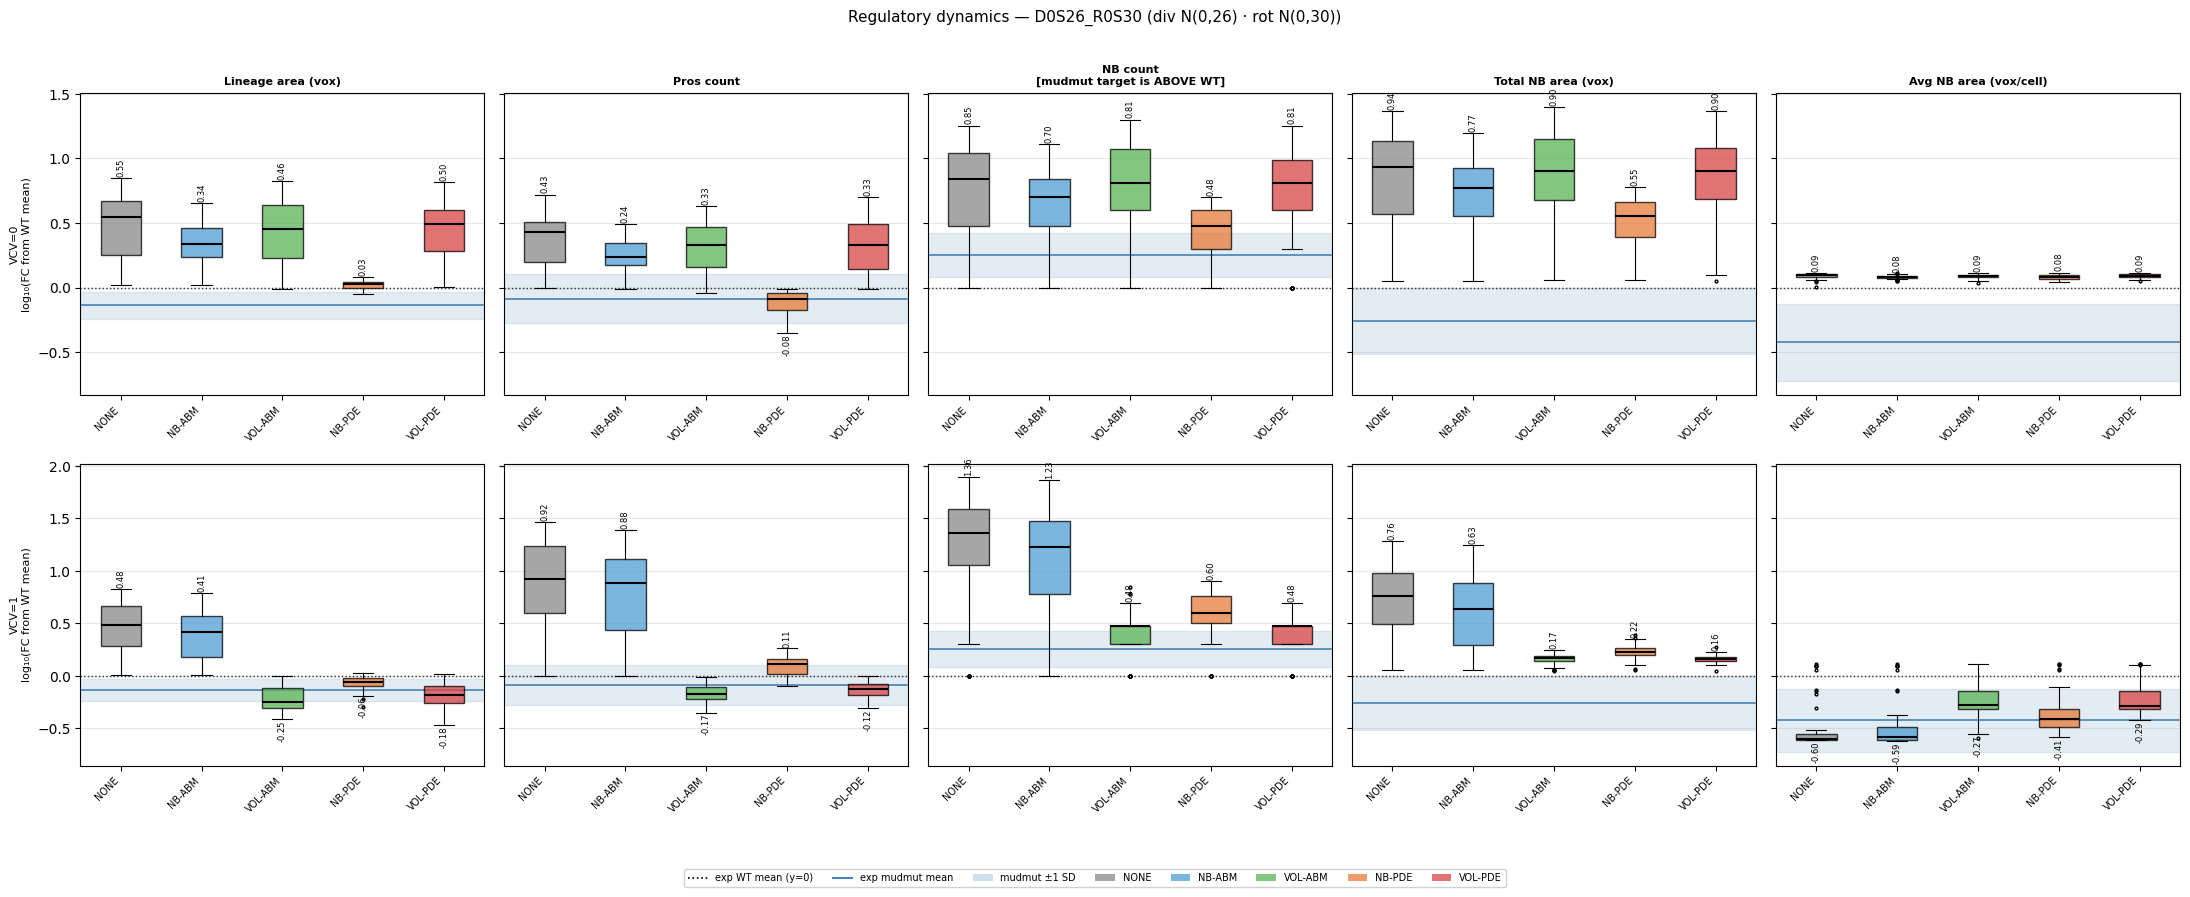

In [46]:
positions = list(range(len(REG_DYN_ORDER)))

fig, axes = plt.subplots(2, len(METRICS), figsize=(22, 9), sharey='row')

for ri, vcv in enumerate([0, 1]):
    for ci, metric in enumerate(METRICS):
        ax = axes[ri, ci]

        wt_mean         = wt_ref[metric][0]
        mm_mean_val, mm_std = mm_ref[metric]
        mm_lfc          = np.log10(mm_mean_val / wt_mean)
        mm_half         = 0.05 if mm_std == 0 else abs(np.log10(1 + mm_std / mm_mean_val))

        ax.axhspan(mm_lfc - mm_half, mm_lfc + mm_half, alpha=0.15, color='steelblue', zorder=0)
        ax.axhline(mm_lfc, color='steelblue', linewidth=1.2, zorder=1)
        ax.axhline(0,      color='black',     linestyle=':', linewidth=1, zorder=1)

        panel = sim_mm[sim_mm['critical_volume_mode'] == vcv]

        data_by_reg = []
        for reg_dyn in REG_DYN_ORDER:
            runs = panel[panel['regulatory_dynamic'] == reg_dyn][metric].dropna()
            data_by_reg.append(
                fold_change_log(runs, wt_mean) if not runs.empty else np.array([np.nan])
            )

        bp = ax.boxplot(
            data_by_reg, positions=positions, widths=0.5,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.5},
            whiskerprops={'linewidth': 0.8},
            capprops={'linewidth': 0.8},
            flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
            zorder=2,
        )
        for patch, reg_dyn in zip(bp['boxes'], REG_DYN_ORDER):
            patch.set_facecolor(REG_DYN_COLORS[reg_dyn])
            patch.set_alpha(0.75)

        for xi, d in enumerate(data_by_reg):
            if np.all(np.isnan(d)):
                continue
            med = float(np.nanmedian(d))
            cap_y = bp['caps'][2*xi + (1 if med >= 0 else 0)].get_ydata()[0]
            offset, va = (0.01, 'bottom') if med >= 0 else (-0.01, 'top')
            ax.text(xi, cap_y + offset, f'{med:.2f}',
                    ha='center', va=va, fontsize=6, rotation=90)

        ax.set_xticks(positions)
        ax.set_xticklabels(REG_DYN_ORDER, rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)

        if ri == 0:
            title_str = METRIC_LABELS[metric]
            if metric == 'n_dpn':
                title_str += '\n[mudmut target is ABOVE WT]'
            ax.set_title(title_str, fontsize=8, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(f'VCV={vcv}\nlog₁₀(FC from WT mean)', fontsize=8)

legend_handles = [
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.2, label='exp WT mean (y=0)'),
    Line2D([0], [0], color='steelblue', linewidth=1.5, label='exp mudmut mean'),
    Patch(facecolor='steelblue', alpha=0.25, label='mudmut ±1 SD'),
] + [
    Patch(facecolor=REG_DYN_COLORS[r], alpha=0.75, label=r) for r in REG_DYN_ORDER
]
fig.suptitle(
    f'Regulatory dynamics — {SIMPLE_TAG} (div N(0,26) · rot N(0,30))',
    fontsize=11,
)
fig.tight_layout(rect=[0, 0.07, 1, 0.97])
fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
           ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
fig.savefig(FIGURES_DIR / 'single_cond_regulatory.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Example Lineages by Regulatory Dynamic

For each metric, one figure: **rows = regulatory dynamic**, **columns = percentile bucket**
(low 10th / mid 50th / high 90th of that metric across all runs in the condition).

Uses **VCV=1** only.  Lineage title shows the metric value and log₁₀ FC from WT mean.

*Note: renders ~75 lineages total — may take a minute.*


── lin_area_vox ──
  Low (10th pctile)     WT-ref    sim64  run 0037  lin_area_vox=5219  logFC=-0.03
  Mid (50th pctile)     WT-ref    sim65  run 0019  lin_area_vox=5639  logFC=+0.01
  High (90th pctile)    WT-ref    sim61  run 0026  lin_area_vox=5905  logFC=+0.03
  Low (10th pctile)     NONE      sim41  run 0045  lin_area_vox=6120  logFC=+0.04
  Low (10th pctile)     NB-ABM    sim42  run 0045  lin_area_vox=6120  logFC=+0.04
  Low (10th pctile)     VOL-ABM   sim43  run 0039  lin_area_vox=2478  logFC=-0.35
  Low (10th pctile)     NB-PDE    sim44  run 0040  lin_area_vox=3907  logFC=-0.15
  Low (10th pctile)     VOL-PDE   sim45  run 0012  lin_area_vox=2447  logFC=-0.36
  Mid (50th pctile)     NONE      sim41  run 0017  lin_area_vox=17057  logFC=+0.49
  Mid (50th pctile)     NB-ABM    sim42  run 0019  lin_area_vox=14953  logFC=+0.43
  Mid (50th pctile)     VOL-ABM   sim43  run 0020  lin_area_vox=3153  logFC=-0.25
  Mid (50th pctile)     NB-PDE    sim44  run 0032  lin_area_vox=4908  logFC=

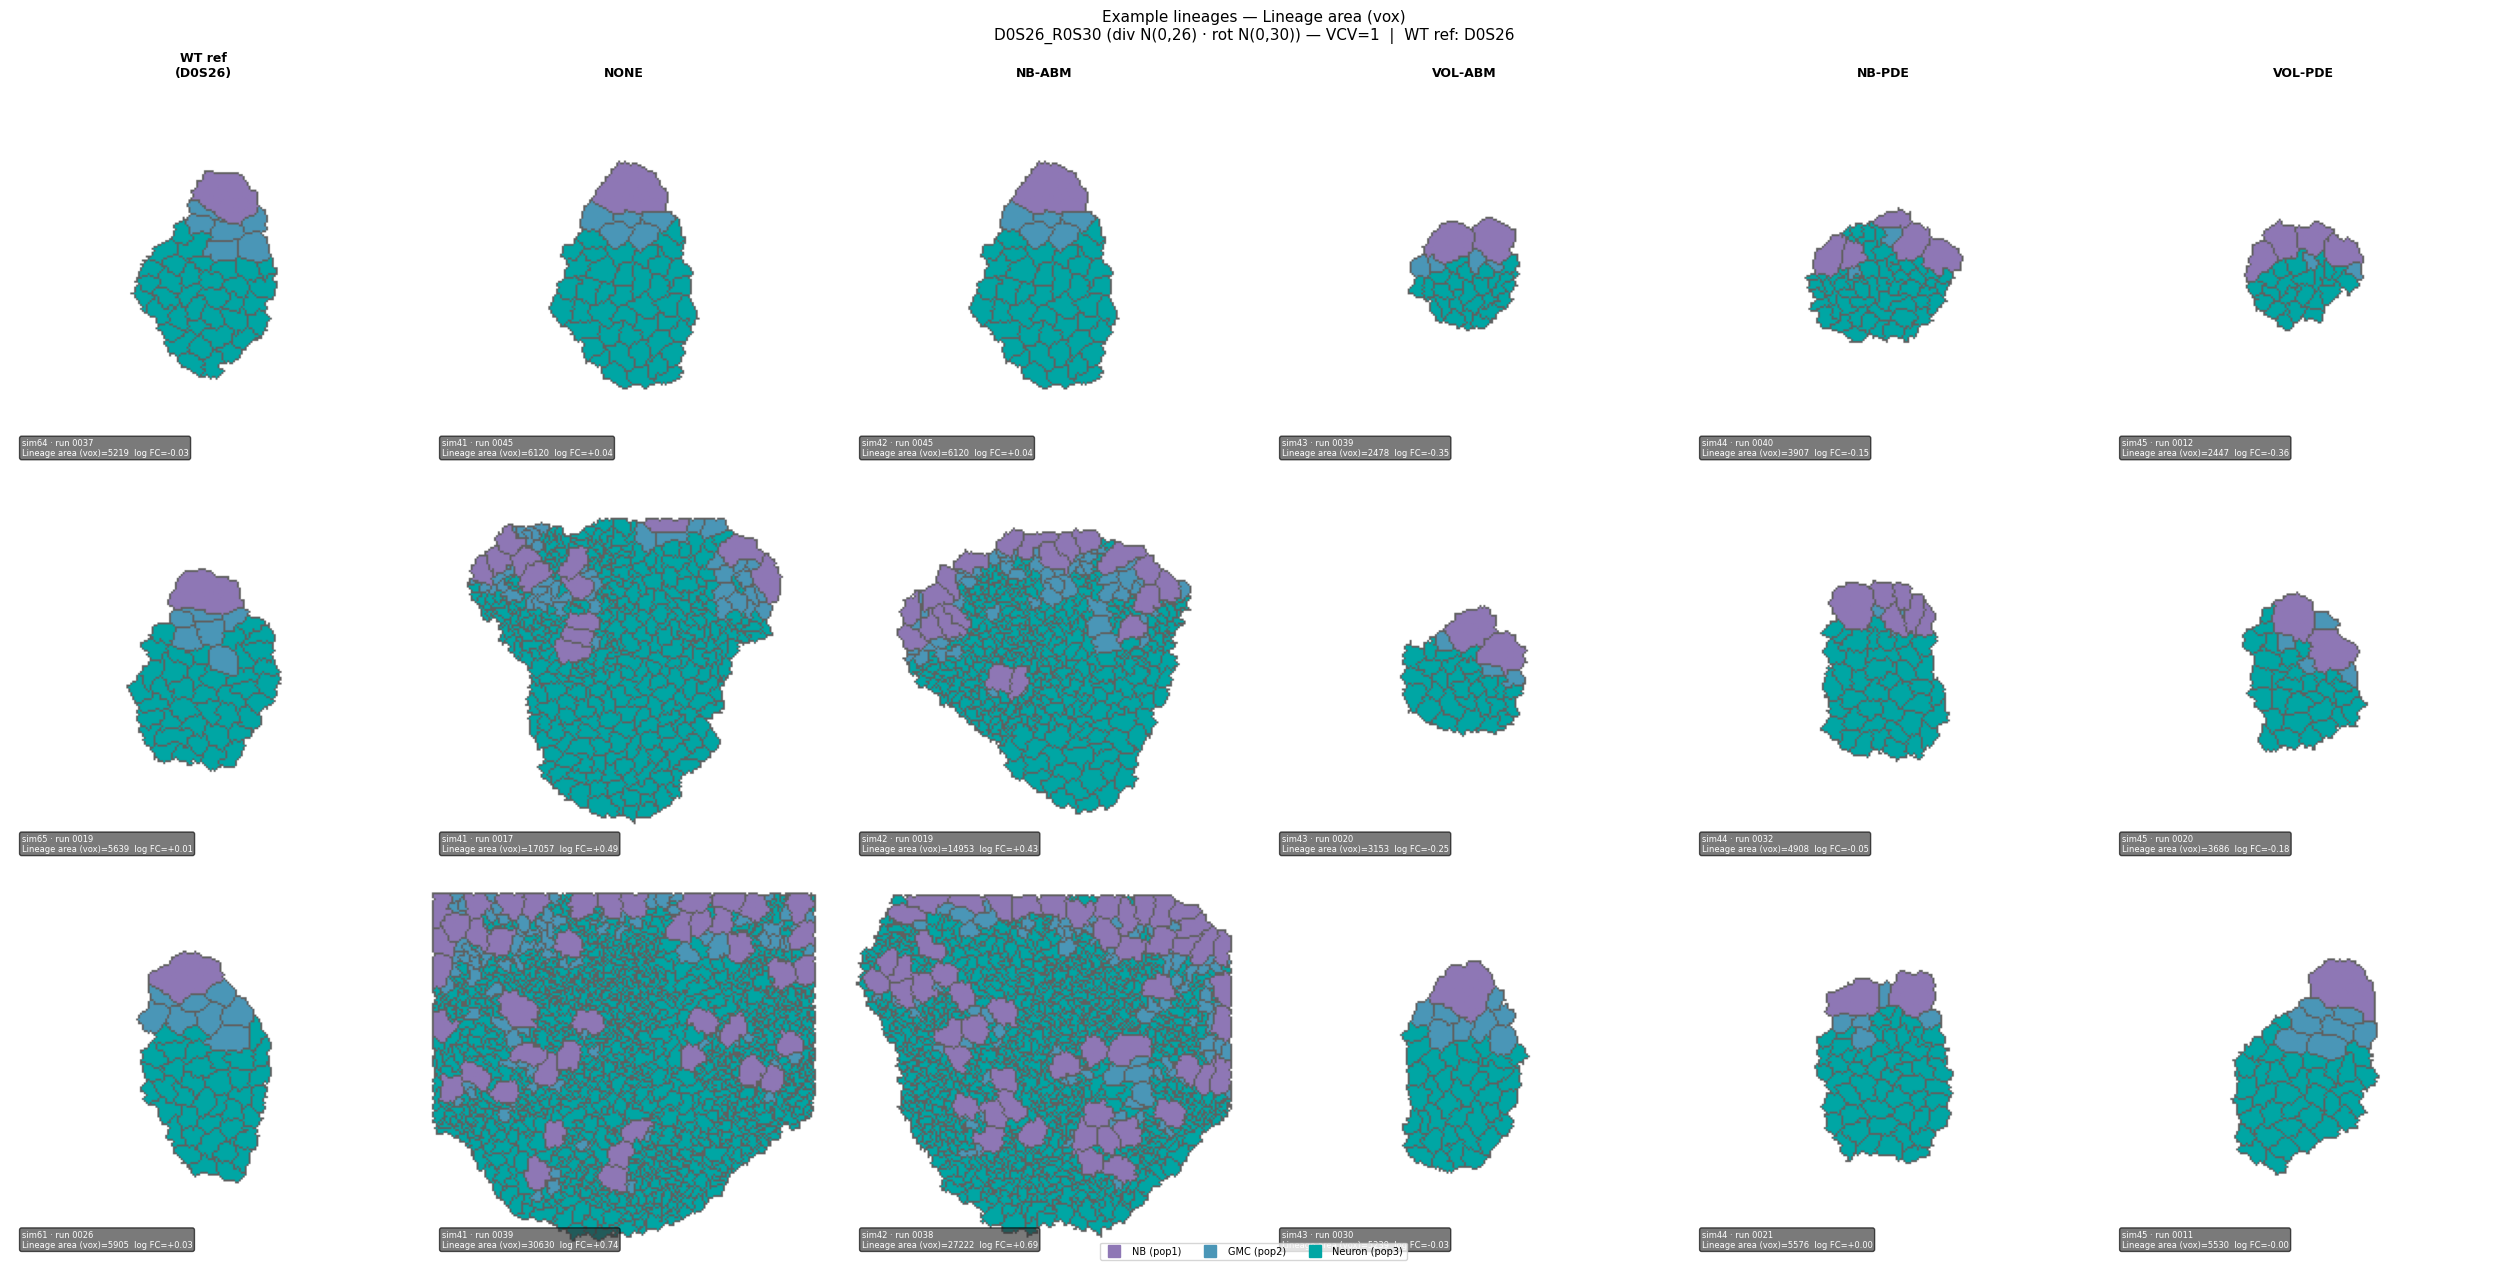


── n_pros ──
  Low (10th pctile)     WT-ref    sim63  run 0007  n_pros=41  logFC=-0.04
  Mid (50th pctile)     WT-ref    sim61  run 0008  n_pros=45  logFC=+0.00
  High (90th pctile)    WT-ref    sim61  run 0034  n_pros=47  logFC=+0.02
  Low (10th pctile)     NONE      sim41  run 0016  n_pros=52  logFC=+0.06
  Low (10th pctile)     NB-ABM    sim42  run 0016  n_pros=50  logFC=+0.05
  Low (10th pctile)     VOL-ABM   sim43  run 0042  n_pros=23  logFC=-0.29
  Low (10th pctile)     NB-PDE    sim44  run 0025  n_pros=41  logFC=-0.04
  Low (10th pctile)     VOL-PDE   sim45  run 0012  n_pros=24  logFC=-0.27
  Mid (50th pctile)     NONE      sim41  run 0033  n_pros=381  logFC=+0.93
  Mid (50th pctile)     NB-ABM    sim42  run 0003  n_pros=359  logFC=+0.90
  Mid (50th pctile)     VOL-ABM   sim43  run 0036  n_pros=31  logFC=-0.16
  Mid (50th pctile)     NB-PDE    sim44  run 0046  n_pros=58  logFC=+0.11
  Mid (50th pctile)     VOL-PDE   sim45  run 0046  n_pros=34  logFC=-0.12
  High (90th pctile)  

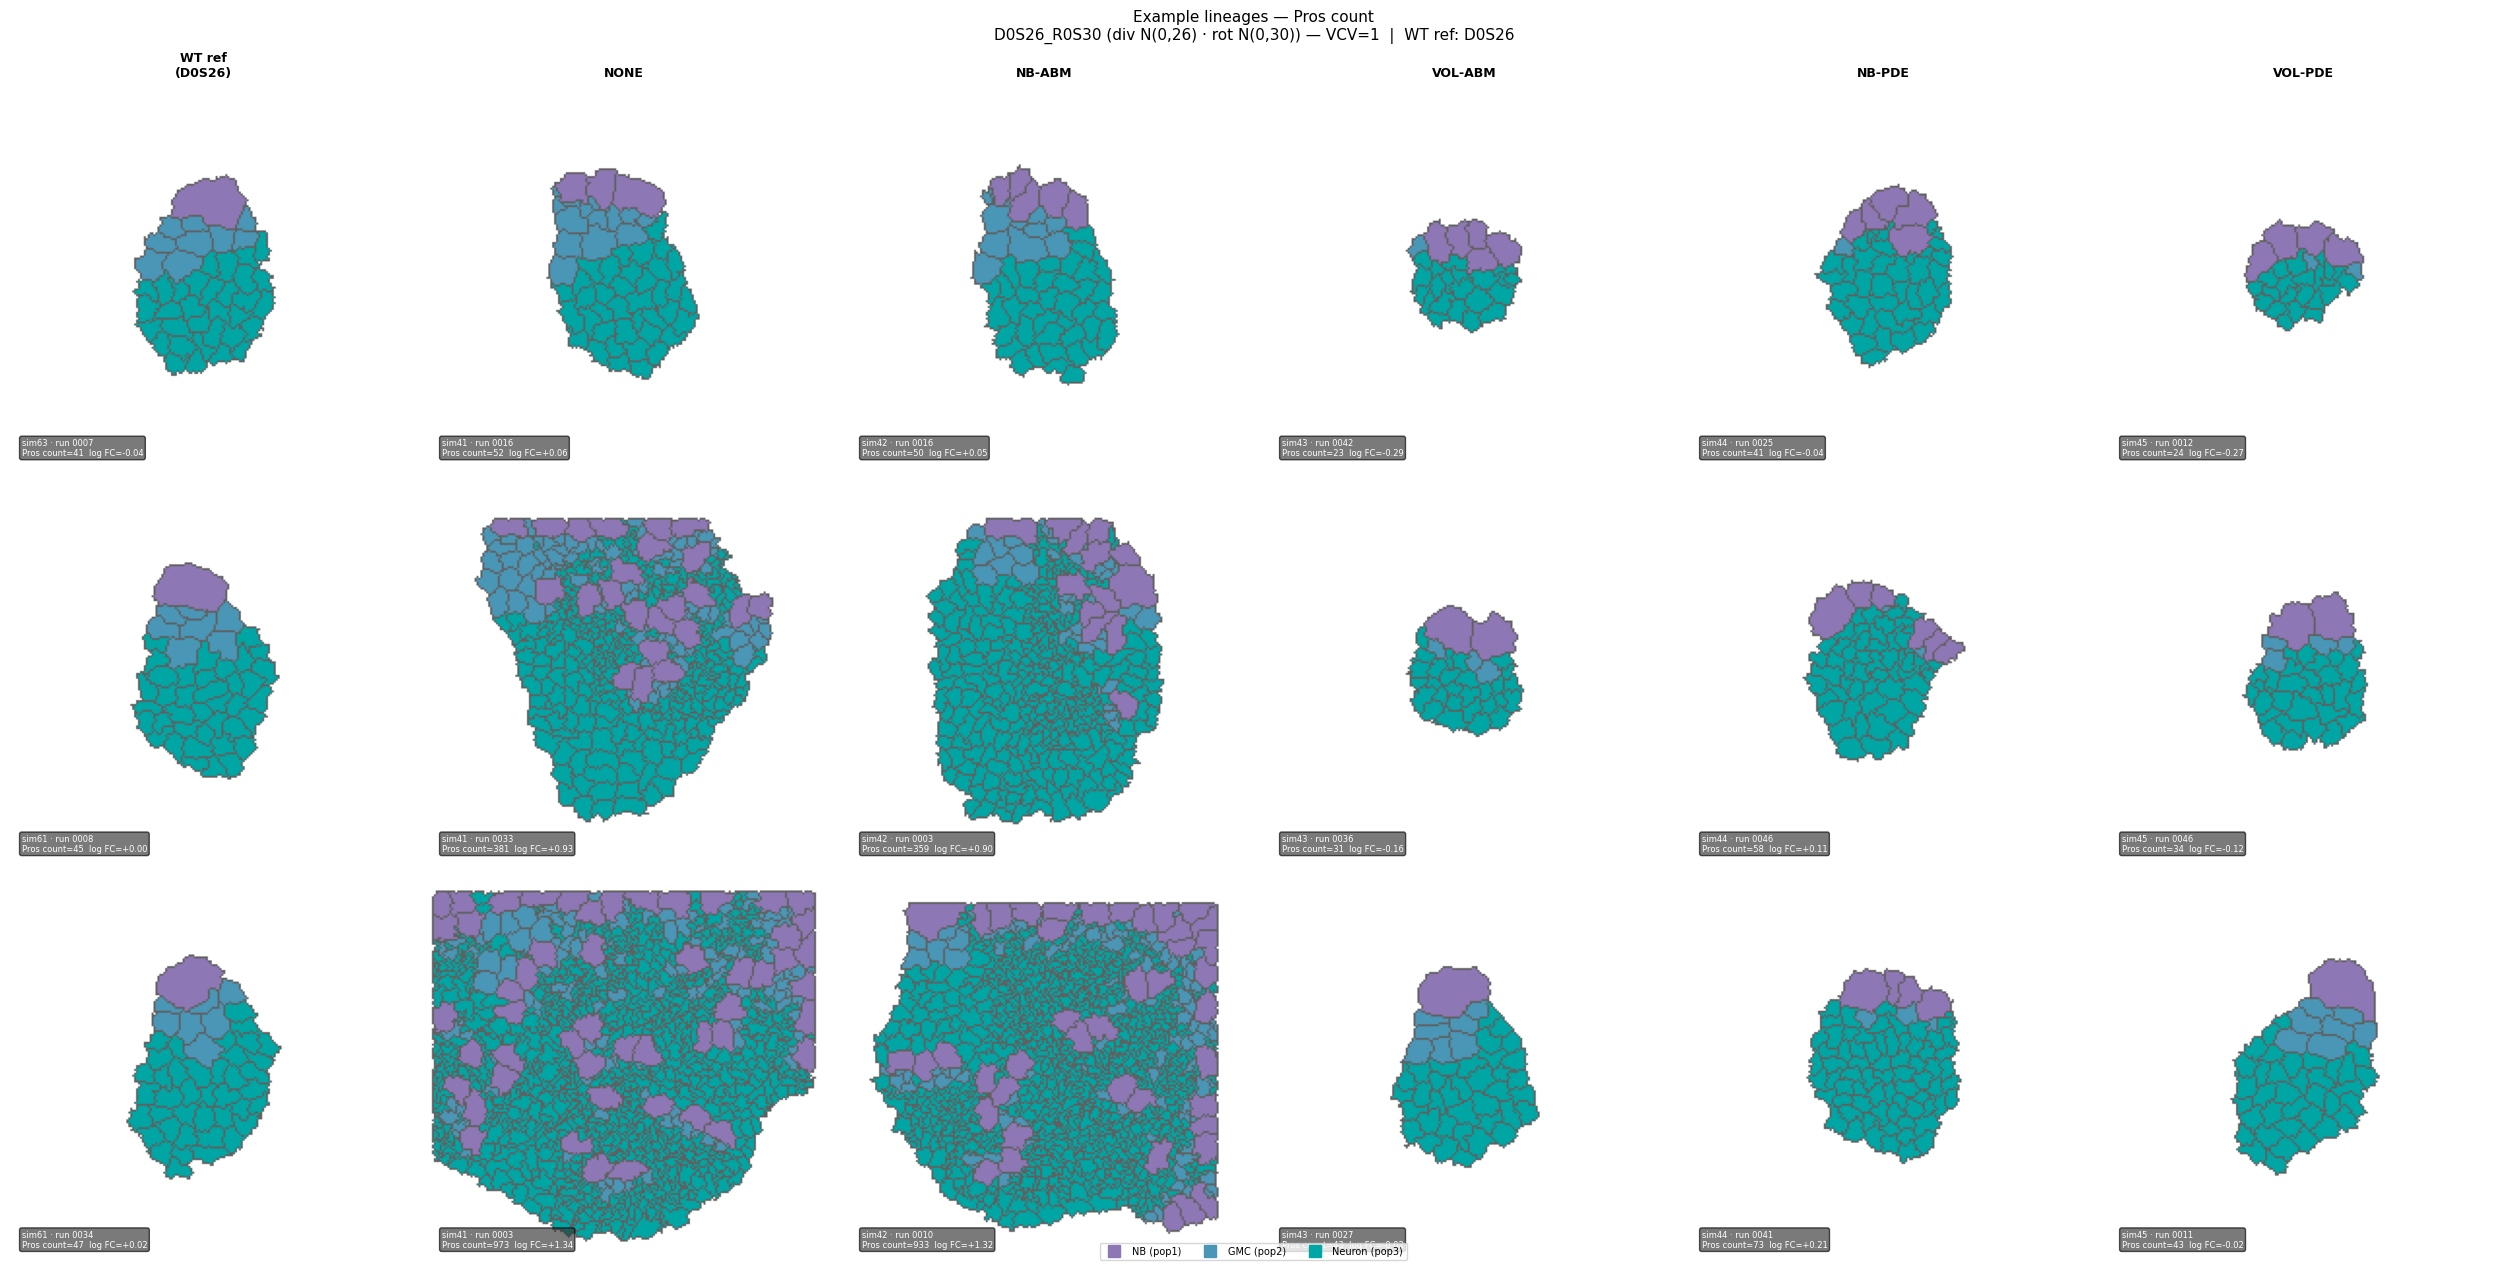


── n_dpn ──
  Low (10th pctile)     WT-ref    sim64  run 0033  n_dpn=1  logFC=+0.00
  Mid (50th pctile)     WT-ref    sim63  run 0024  n_dpn=1  logFC=+0.00
  High (90th pctile)    WT-ref    sim62  run 0020  n_dpn=1  logFC=+0.00
  Low (10th pctile)     NONE      sim41  run 0035  n_dpn=2  logFC=+0.30
  Low (10th pctile)     NB-ABM    sim42  run 0031  n_dpn=2  logFC=+0.30
  Low (10th pctile)     VOL-ABM   sim43  run 0014  n_dpn=1  logFC=+0.00
  Low (10th pctile)     NB-PDE    sim44  run 0023  n_dpn=2  logFC=+0.30
  Low (10th pctile)     VOL-PDE   sim45  run 0011  n_dpn=1  logFC=+0.00
  Mid (50th pctile)     NONE      sim41  run 0033  n_dpn=23  logFC=+1.36
  Mid (50th pctile)     NB-ABM    sim42  run 0002  n_dpn=17  logFC=+1.23
  Mid (50th pctile)     VOL-ABM   sim43  run 0046  n_dpn=3  logFC=+0.48
  Mid (50th pctile)     NB-PDE    sim44  run 0041  n_dpn=4  logFC=+0.60
  Mid (50th pctile)     VOL-PDE   sim45  run 0042  n_dpn=3  logFC=+0.48
  High (90th pctile)    NONE      sim41  run 0003

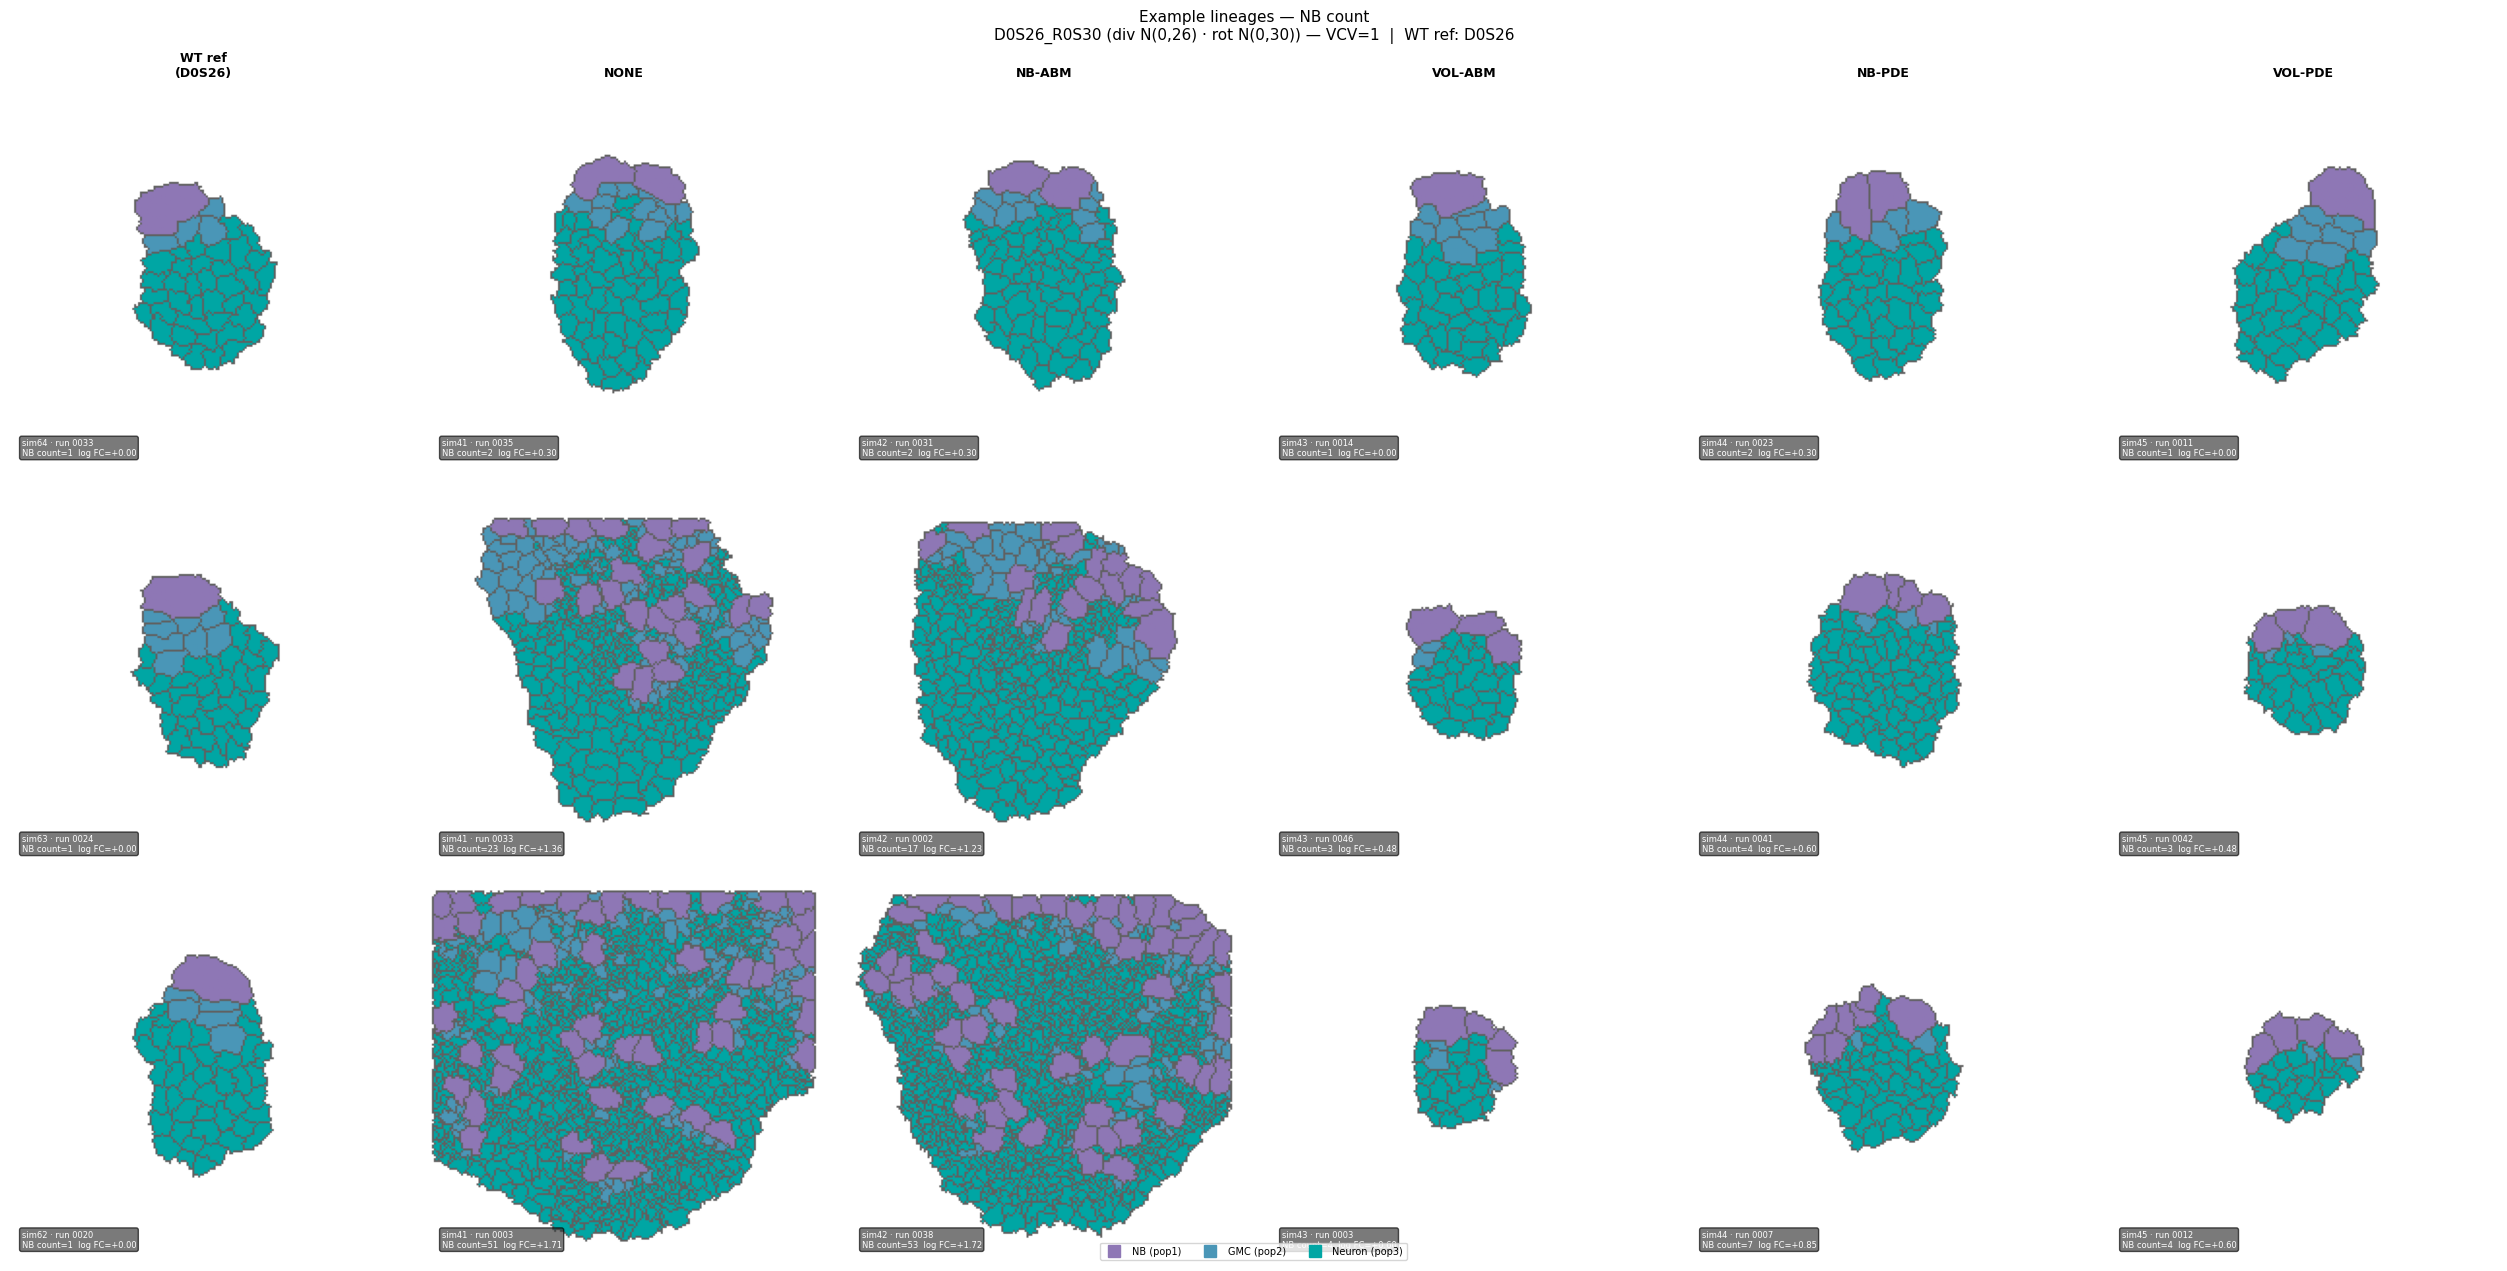


── dpn_area_vox ──
  Low (10th pctile)     WT-ref    sim63  run 0037  dpn_area_vox=650  logFC=+0.05
  Mid (50th pctile)     WT-ref    sim61  run 0038  dpn_area_vox=724  logFC=+0.10
  High (90th pctile)    WT-ref    sim64  run 0048  dpn_area_vox=750  logFC=+0.11
  Low (10th pctile)     NONE      sim41  run 0034  dpn_area_vox=780  logFC=+0.13
  Low (10th pctile)     NB-ABM    sim42  run 0034  dpn_area_vox=831  logFC=+0.16
  Low (10th pctile)     VOL-ABM   sim43  run 0027  dpn_area_vox=738  logFC=+0.11
  Low (10th pctile)     NB-PDE    sim44  run 0015  dpn_area_vox=747  logFC=+0.11
  Low (10th pctile)     VOL-PDE   sim45  run 0011  dpn_area_vox=745  logFC=+0.11
  Mid (50th pctile)     NONE      sim41  run 0026  dpn_area_vox=3344  logFC=+0.76
  Mid (50th pctile)     NB-ABM    sim42  run 0002  dpn_area_vox=2617  logFC=+0.66
  Mid (50th pctile)     VOL-ABM   sim43  run 0031  dpn_area_vox=849  logFC=+0.17
  Mid (50th pctile)     NB-PDE    sim44  run 0042  dpn_area_vox=970  logFC=+0.23
  Mid 

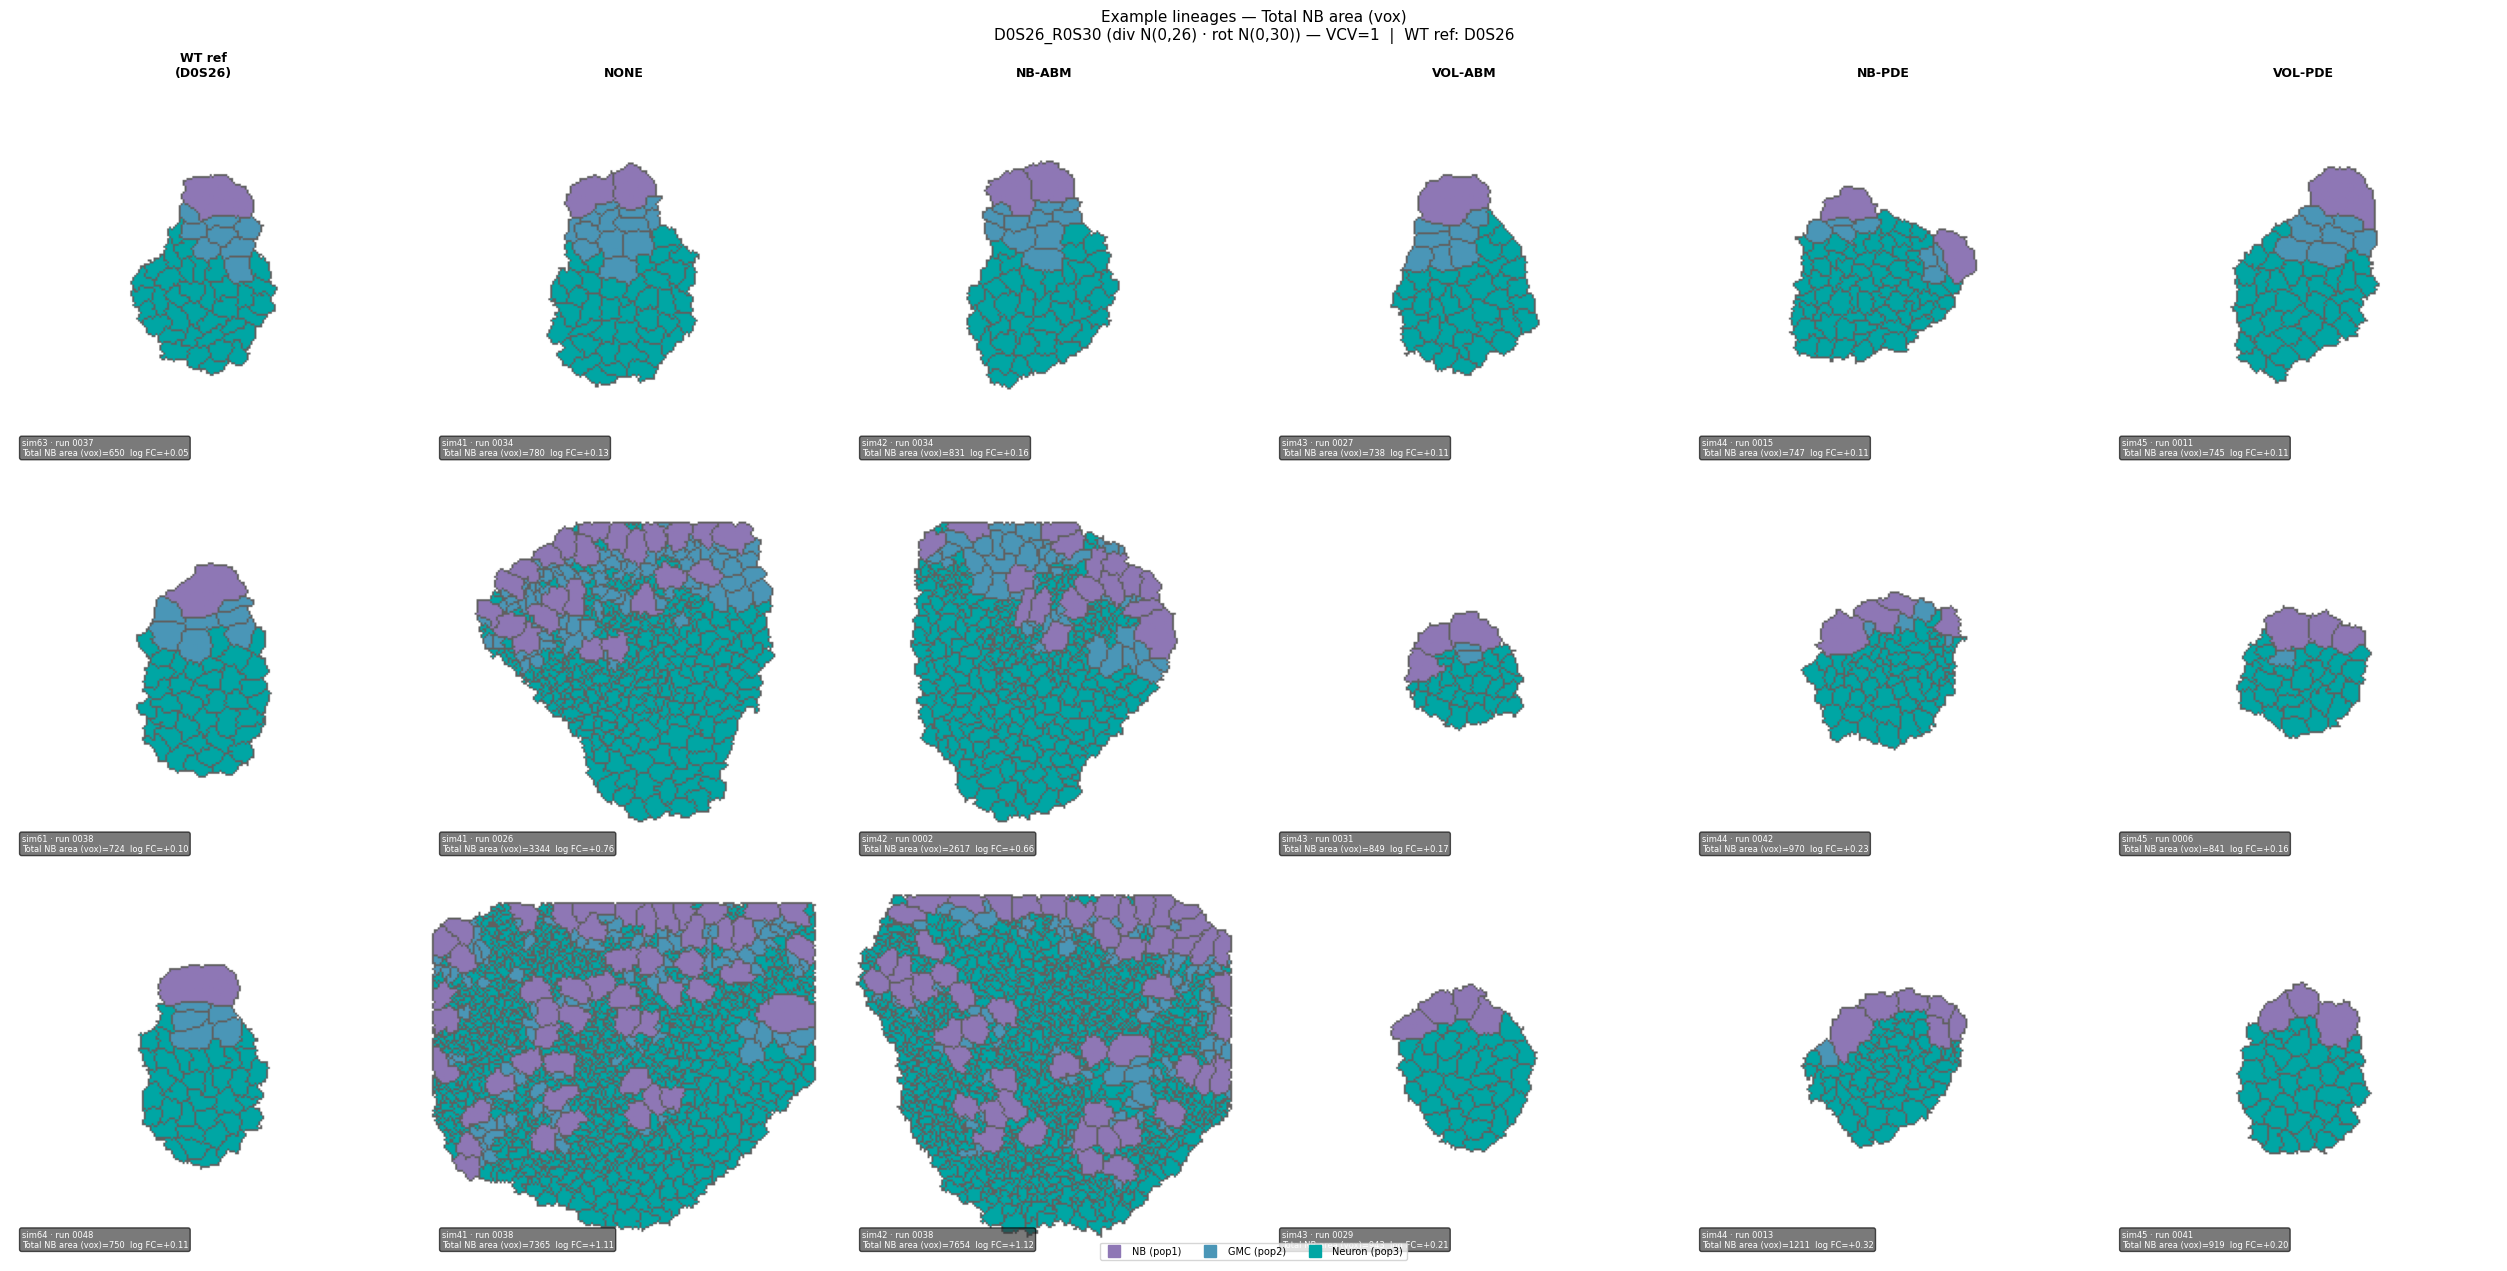


── avg_dpn_area_vox ──
  Low (10th pctile)     WT-ref    sim63  run 0037  avg_dpn_area_vox=650  logFC=+0.05
  Mid (50th pctile)     WT-ref    sim61  run 0038  avg_dpn_area_vox=724  logFC=+0.10
  High (90th pctile)    WT-ref    sim64  run 0048  avg_dpn_area_vox=750  logFC=+0.11
  Low (10th pctile)     NONE      sim41  run 0001  avg_dpn_area_vox=142  logFC=-0.61
  Low (10th pctile)     NB-ABM    sim42  run 0044  avg_dpn_area_vox=139  logFC=-0.62
  Low (10th pctile)     VOL-ABM   sim43  run 0015  avg_dpn_area_vox=221  logFC=-0.42
  Low (10th pctile)     NB-PDE    sim44  run 0024  avg_dpn_area_vox=176  logFC=-0.52
  Low (10th pctile)     VOL-PDE   sim45  run 0012  avg_dpn_area_vox=242  logFC=-0.38
  Mid (50th pctile)     NONE      sim41  run 0047  avg_dpn_area_vox=146  logFC=-0.60
  Mid (50th pctile)     NB-ABM    sim42  run 0043  avg_dpn_area_vox=151  logFC=-0.58
  Mid (50th pctile)     VOL-ABM   sim43  run 0044  avg_dpn_area_vox=308  logFC=-0.27
  Mid (50th pctile)     NB-PDE    sim44  

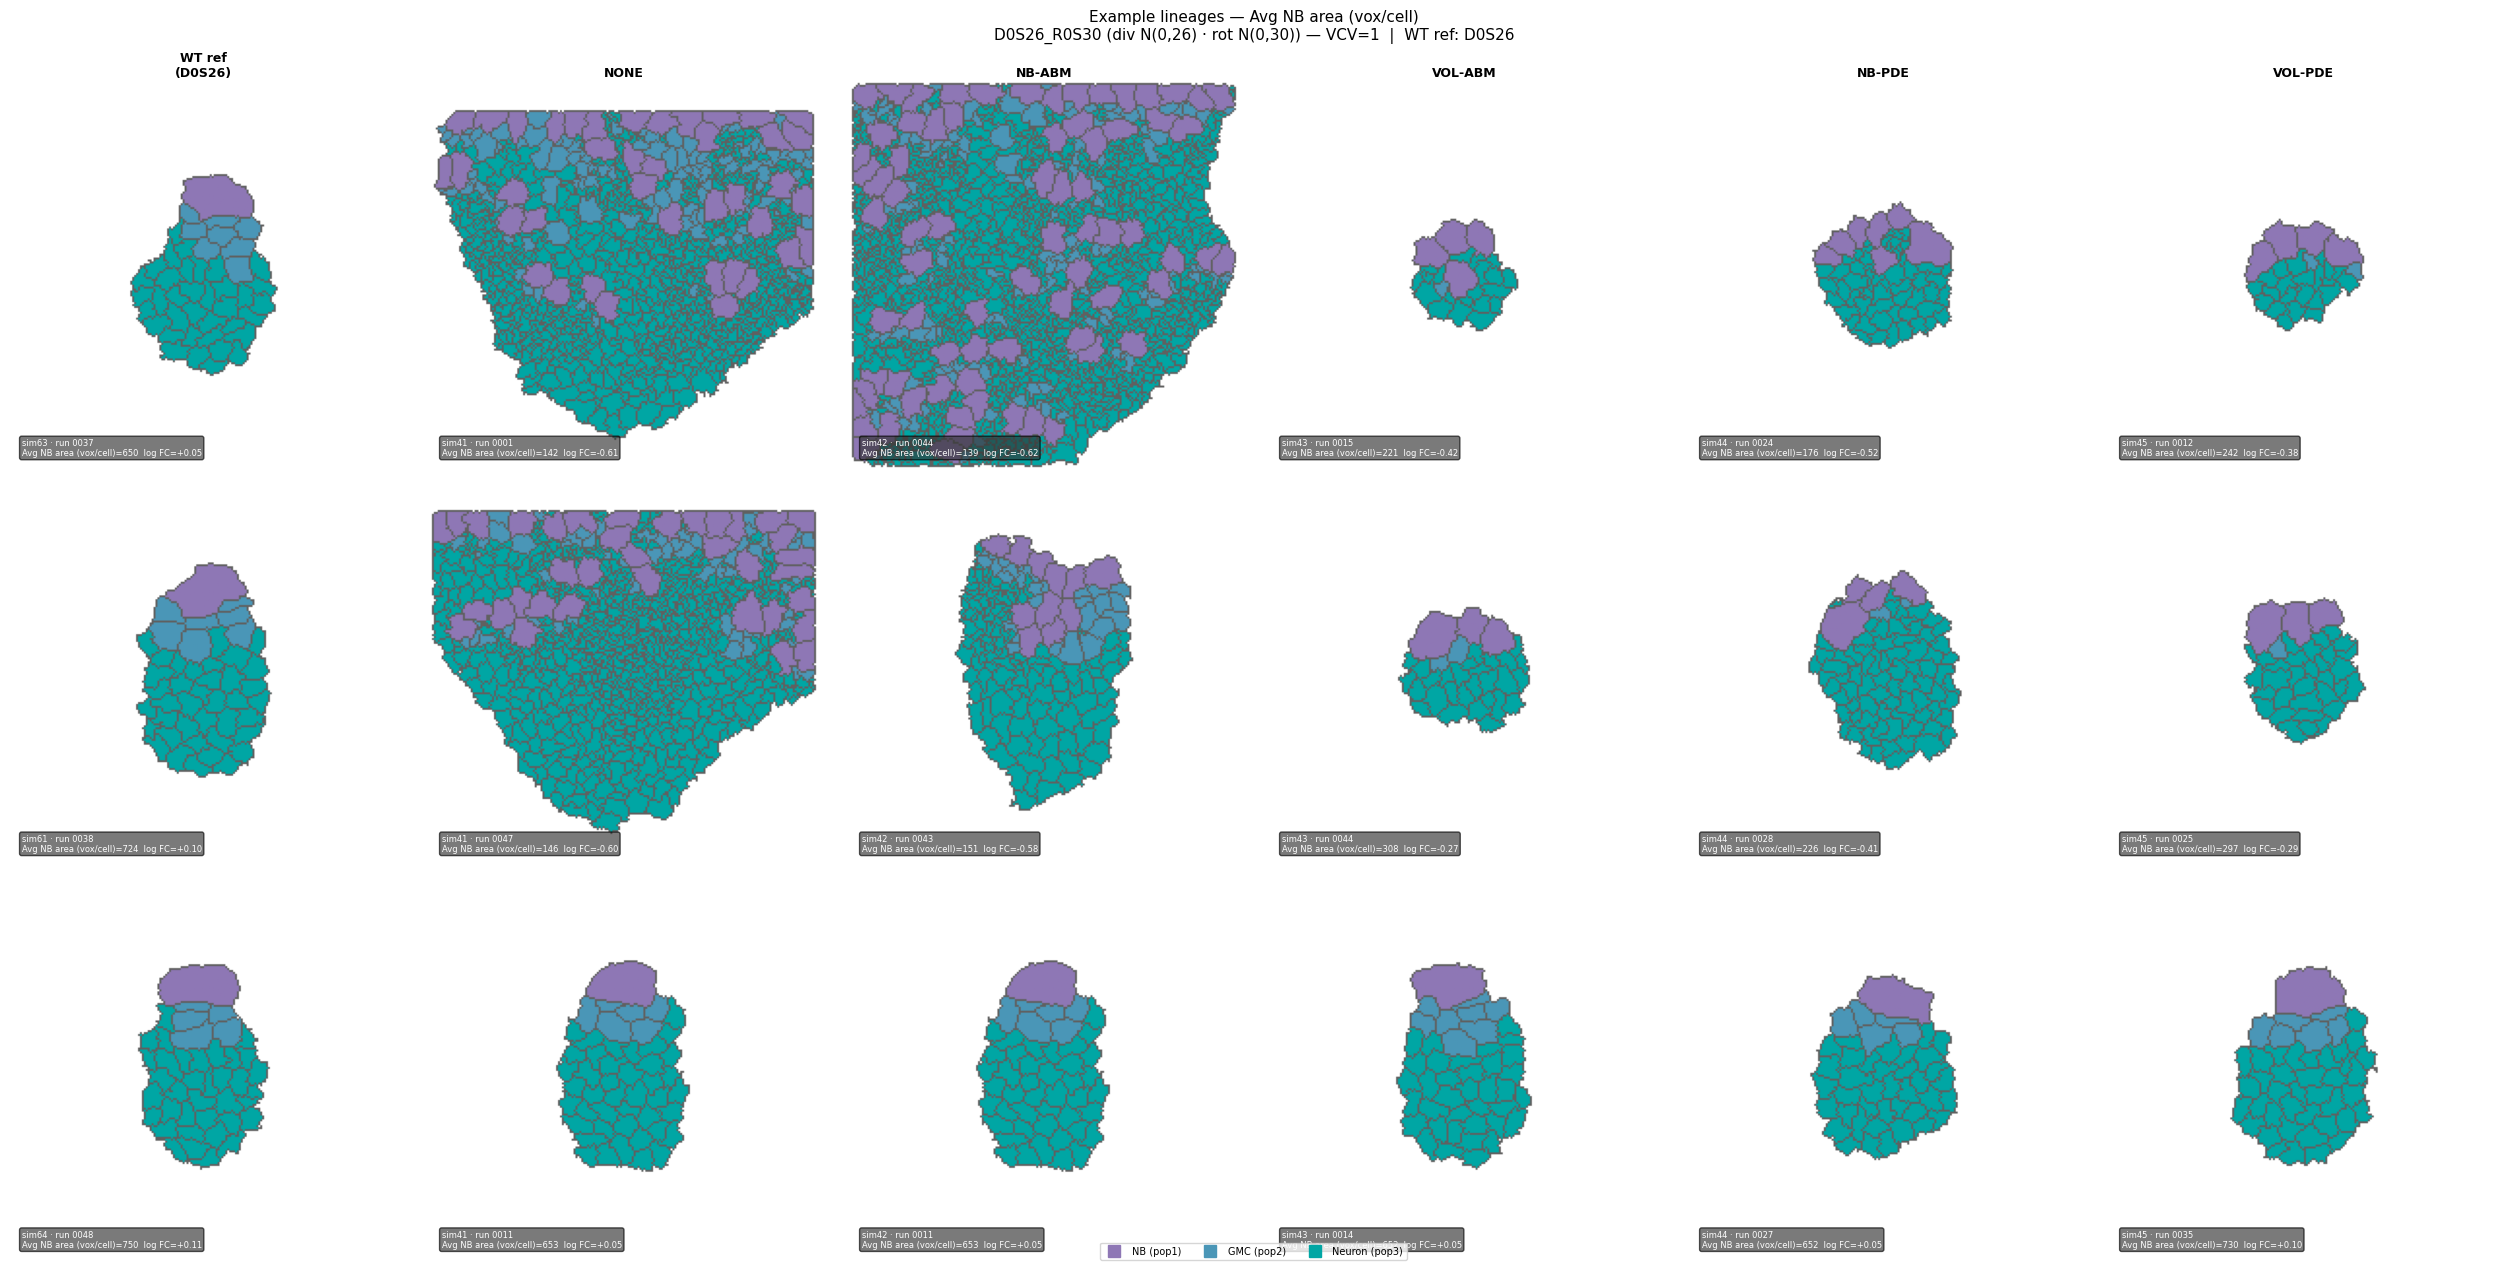

In [36]:
_PCTILES = [
    (0.10, 'Low (10th pctile)'),
    (0.50, 'Mid (50th pctile)'),
    (0.90, 'High (90th pctile)'),
]

# Column 0 = WT reference; columns 1..N = regulatory dynamics
_N_COLS = 1 + len(REG_DYN_ORDER)

for metric in METRICS:
    fig, axes = plt.subplots(
        len(_PCTILES), _N_COLS,
        figsize=(4.2 * _N_COLS, 4.2 * len(_PCTILES)),
        constrained_layout=True,
    )

    wt_mean  = wt_ref[metric][0]
    wt_panel = (
        sim_wt[sim_wt['critical_volume_mode'] == 1]
        .dropna(subset=[metric])
        .sort_values(metric)
        .reset_index(drop=True)
    )
    n_wt = len(wt_panel)
    print(f'\n── {metric} ──')

    # ── WT reference column (far left) ───────────────────────────────────────
    for ri, (pctile, plabel) in enumerate(_PCTILES):
        ax = axes[ri, 0]
        if n_wt == 0:
            ax.axis('off')
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')
            continue

        idx = min(n_wt - 1, int(n_wt * pctile))
        row = wt_panel.iloc[idx]
        val = float(row[metric])
        lfc = np.log10(val / wt_mean) if wt_mean > 0 else float('nan')
        sid = str(row['sim_id'])
        rid = str(int(row['run_id'])).zfill(4)

        print(f'  {plabel:<20}  {"WT-ref":<8}  {sid}  run {rid}  '
              f'{metric}={val:.0f}  logFC={lfc:+.2f}')

        try:
            draw_example_lineage(
                condition=WT_COND,
                sim_id=sid,
                run_id=rid,
                title='',
                ax=ax,
            )
            ax.text(
                0.03, 0.03,
                f'{sid} · run {rid}\n{METRIC_LABELS[metric]}={val:.0f}  log FC={lfc:+.2f}',
                transform=ax.transAxes, fontsize=6, va='bottom', ha='left',
                color='white',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='#333333', alpha=0.65),
            )
        except Exception as e:
            ax.text(0.5, 0.5, str(e), ha='center', va='center',
                    transform=ax.transAxes, fontsize=5, color='red')
            ax.axis('off')

    # ── mudmut regulatory dynamic columns ────────────────────────────────────
    for ri, (pctile, plabel) in enumerate(_PCTILES):
        for ci, reg_dyn in enumerate(REG_DYN_ORDER):
            ax = axes[ri, ci + 1]
            panel = (
                sim_mm[
                    (sim_mm['critical_volume_mode'] == 1) &
                    (sim_mm['regulatory_dynamic'] == reg_dyn)
                ]
                .dropna(subset=[metric])
                .sort_values(metric)
                .reset_index(drop=True)
            )

            n = len(panel)
            if n == 0:
                ax.axis('off')
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
                continue

            idx = min(n - 1, int(n * pctile))
            row = panel.iloc[idx]
            val = float(row[metric])
            lfc = np.log10(val / wt_mean) if wt_mean > 0 else float('nan')
            sid = str(row['sim_id'])
            rid = str(int(row['run_id'])).zfill(4)

            print(f'  {plabel:<20}  {reg_dyn:<8}  {sid}  run {rid}  '
                  f'{metric}={val:.0f}  logFC={lfc:+.2f}')

            try:
                draw_example_lineage(
                    condition=SIMPLE_COND,
                    sim_id=sid,
                    run_id=rid,
                    title='',
                    ax=ax,
                )
                ax.text(
                    0.03, 0.03,
                    f'{sid} · run {rid}\n{METRIC_LABELS[metric]}={val:.0f}  log FC={lfc:+.2f}',
                    transform=ax.transAxes, fontsize=6, va='bottom', ha='left',
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.25', facecolor='#333333', alpha=0.65),
                )
            except Exception as e:
                ax.text(0.5, 0.5, str(e), ha='center', va='center',
                        transform=ax.transAxes, fontsize=5, color='red')
                ax.axis('off')

    # ── Set labels AFTER drawing so render_raw can't overwrite them ───────────
    axes[0, 0].set_title(f'WT ref\n({WT_TAG})', fontsize=9, fontweight='bold', pad=4)
    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        axes[0, ci + 1].set_title(reg_dyn, fontsize=9, fontweight='bold', pad=4)

    for ri, (_, plabel) in enumerate(_PCTILES):
        axes[ri, 0].set_ylabel(plabel, fontsize=9)

    # Colour legend
    from matplotlib.lines import Line2D as _L2D
    legend_handles = [
        _L2D([0],[0], color=NB_COLOR,    marker='s', markersize=8, linestyle='none', label='NB (pop1)'),
        _L2D([0],[0], color=POP2_COLOR,  marker='s', markersize=8, linestyle='none', label='GMC (pop2)'),
        _L2D([0],[0], color=POP3_COLOR,  marker='s', markersize=8, linestyle='none', label='Neuron (pop3)'),
    ]
    fig.legend(handles=legend_handles, fontsize=7, loc='lower center',
               ncol=3, bbox_to_anchor=(0.5, 0))
    fig.suptitle(
        f'Example lineages — {METRIC_LABELS[metric]}\n'
        f'{SIMPLE_TAG} (div N(0,26) · rot N(0,30)) — VCV=1  |  WT ref: {WT_TAG}',
        fontsize=11,
    )
    fig.savefig(FIGURES_DIR / f'lineages_single_{metric}.png', dpi=100, bbox_inches='tight')
    plt.show()